## Descriptive Statistics

In [56]:
import pandas as pd

df = pd.read_csv("dataset/all_ai_models.csv")

print(f"Shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.describe(include='all')

Shape: (3237, 57)

Column names:
['Model', 'Domain', 'Task', 'Organization', 'Authors', 'Publication date', 'Reference', 'Link', 'Citations', 'Notability criteria', 'Notability criteria notes', 'Parameters', 'Parameters notes', 'Training compute (FLOP)', 'Training compute notes', 'Training dataset size (total)', 'Dataset size notes', 'Training time (hours)', 'Training time notes', 'Training hardware', 'Approach', 'Confidence', 'Abstract', 'Epochs', 'WikiText and Penn Treebank data', 'Model accessibility', 'Country (of organization)', 'Base model', 'Finetune compute (FLOP)', 'Finetune compute notes', 'Hardware quantity', 'Hardware utilization (MFU)', 'Last modified', 'Training cloud compute vendor', 'Training data center', 'Archived links', 'Batch size', 'Batch size notes', 'Organization categorization', 'Foundation model', 'Training compute lower bound', 'Training compute upper bound', 'Training chip-hours', 'Training code accessibility', 'Accessibility notes', 'Possibly over 1e23 FLOP

,Model,Domain,Task,Organization,Authors,Publication date,Reference,Link,Citations,Notability criteria,...,Utilization notes,Numerical format,Frontier model,Training power draw (W),Training compute estimation method,Hugging Face developer id,Post-training compute (FLOP),Post-training compute notes,Hardware utilization (HFU),Open model weights?
count,3237,3153,3119,3157,2466,3219,3076,3202,1270.000000,932,...,88,339,137,7.650000e+02,1438,609,1.000000e+00,1,25.000000,2488
unique,3236,172,894,1245,1919,1540,2453,2639,NaN,39,...,84,6,1,NaN,38,192,NaN,1,NaN,2
top,Tulu 3 (Tülu 3) 70B,Language,Language modeling,OpenAI,Qwen Team,2024-09-24,CAC registry,https://arxiv.org/abs/2205.01068,NaN,SOTA improvement,...,"Table 4: Training metric comparison\n\n""Causal...",BF16,True,NaN,Operation counting,Qwen,NaN,Section 4 gives detail about the post-training...,NaN,Yes
freq,2,1415,274,108,16,16,48,14,NaN,447,...,2,123,137,NaN,638,55,NaN,1,NaN,1260
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4147.406299,NaN,...,NaN,NaN,NaN,7.719242e+05,NaN,NaN,9.400000e+22,NaN,0.490876,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14666.204339,NaN,...,NaN,NaN,NaN,4.887626e+06,NaN,NaN,NaN,NaN,0.148841,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,...,NaN,NaN,NaN,7.582593e+01,NaN,NaN,9.400000e+22,NaN,0.235900,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52.250000,NaN,...,NaN,NaN,NaN,4.153310e+03,NaN,NaN,9.400000e+22,NaN,0.400000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,409.000000,NaN,...,NaN,NaN,NaN,2.551799e+04,NaN,NaN,9.400000e+22,NaN,0.493500,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2441.750000,NaN,...,NaN,NaN,NaN,2.024958e+05,NaN,NaN,9.400000e+22,NaN,0.577200,NaN


## Cleaning

In [57]:
import pandas as pd

df = pd.read_csv("dataset/all_ai_models.csv")

results = []
for col in df.columns:
    s = df[col].astype(str).str.strip()
    has_true  = s.str.lower().eq("true").any()
    has_false = s.str.lower().eq("false").any()
    has_empty = (s.eq("") | df[col].isna()).any()
    if has_true or has_false:
        results.append({
            "column": col,
            "has_true":  has_true,
            "has_false": has_false,
            "has_empty": has_empty,
            "empty_means_false": has_true and not has_false and has_empty,
        })

pd.DataFrame(results).set_index("column")

,has_true,has_false,has_empty,empty_means_false
column,,,,
Foundation model,True,False,True,True
Possibly over 1e23 FLOP,True,False,True,True
Frontier model,True,False,True,True


**Encoding note — `True`/empty boolean columns:**
Three columns (`Foundation model`, `Frontier model`, `Possibly over 1e23 FLOP`) store booleans as `"True"` or blank — there are no `"False"` values at all. Empty therefore means False. These are recoded to `1`/`0` in the cleaned dataset.

In [58]:
true_empty_cols = ["Foundation model", "Frontier model", "Possibly over 1e23 FLOP"]

cleaned = df.copy()
for col in true_empty_cols:
    cleaned[col] = cleaned[col].astype(str).str.strip().eq("True").astype(int)

cleaned.to_csv("dataset/cleaned_ai_models.csv", index=False)
print(f"Saved {len(cleaned)} rows to dataset/cleaned_ai_models.csv")
cleaned[true_empty_cols].value_counts().head(10)

Saved 3237 rows to dataset/cleaned_ai_models.csv


Foundation model  Frontier model  Possibly over 1e23 FLOP
0                 0               0                          2614
                                  1                           424
                  1               0                            92
1                 0               1                            33
0                 1               1                            31
1                 0               0                            29
                  1               1                            13
                                  0                             1
Name: count, dtype: int64

## Correlation Matrix

N (rows with ≥1 value): 3237
N (complete cases): 161



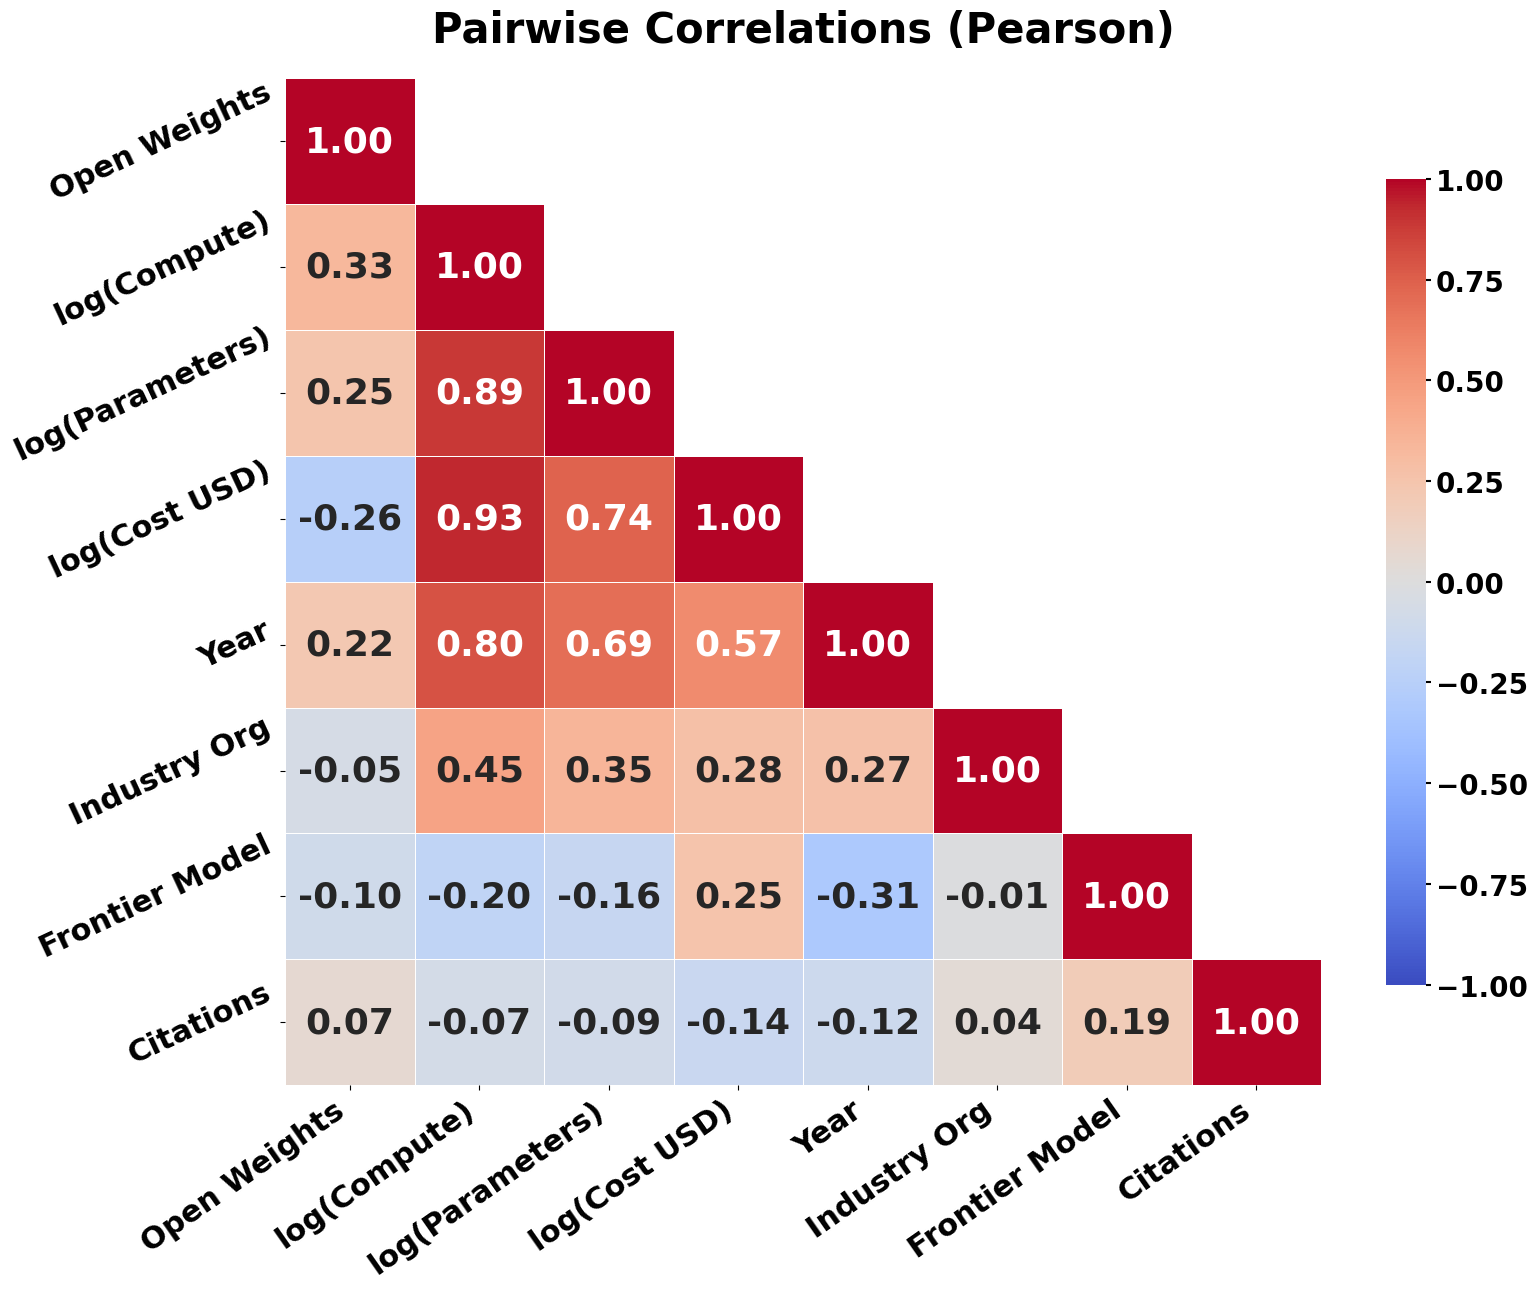

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("dataset/cleaned_ai_models.csv")

# --- Encode variables ---
df["open"] = df["Open model weights?"].map({"Yes": 1, "No": 0})
df["log_compute"] = np.log10(pd.to_numeric(df["Training compute (FLOP)"], errors="coerce"))
df["log_params"]  = np.log10(pd.to_numeric(df["Parameters"], errors="coerce"))
df["log_cost"]    = np.log10(pd.to_numeric(df["Training compute cost (2023 USD)"], errors="coerce"))
df["year"]        = pd.to_datetime(df["Publication date"], errors="coerce").dt.year
df["is_industry"] = df["Organization categorization"].str.lower().str.contains("industry", na=False).astype(float)
df["citations"]   = pd.to_numeric(df["Citations"], errors="coerce")

cols = {
    "open":           "Open Weights",
    "log_compute":    "log(Compute)",
    "log_params":     "log(Parameters)",
    "log_cost":       "log(Cost USD)",
    "year":           "Year",
    "is_industry":    "Industry Org",
    "Frontier model": "Frontier Model",
    "citations":      "Citations",
}

corr_df = df[list(cols.keys())].rename(columns=cols)
corr = corr_df.corr()

print(f"N (rows with ≥1 value): {len(corr_df)}")
print(f"N (complete cases): {corr_df.dropna().shape[0]}\n")

plt.rcParams["font.family"] = "DejaVu Sans"

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
    linewidths=0.6, ax=ax, mask=mask, vmin=-1, vmax=1,
    annot_kws={"size": 26, "weight": "bold", "family": "DejaVu Sans"},
    cbar_kws={"shrink": 0.8},
)

ax.set_title("Pairwise Correlations (Pearson)", fontsize=30, fontweight="bold", pad=26)

ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=22, fontweight="bold")
ax.set_yticklabels(ax.get_yticklabels(), rotation=25, ha="right", fontsize=22, fontweight="bold")

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=20, width=1.5)
for label in cbar.ax.get_yticklabels():
    label.set_fontweight("bold")
    label.set_fontsize(20)

plt.tight_layout()
plt.show()

## Composite Openness Score

The dependent variable is a **0–2 openness score** built from two independent signals:

| Component | Column | Open = 1 if... |
|---|---|---|
| Model weights | `Open model weights?` | `"Yes"` |
| Training code | `Training code accessibility` | starts with `"Open"` |

**Score interpretation:**
- `0` — Neither weights nor code are open
- `1` — Only one of the two is open  
- `2` — Both weights and code are open

Rows where both columns are missing are excluded.

=== Composite Openness Score Distribution ===
       Count  Percent (%)
Score                    
0       1759         54.3
1        978         30.2
2        500         15.4

Total scored models: 3237
  Score 0 (fully closed):   1759 (54.3%)
  Score 1 (partially open): 978 (30.2%)
  Score 2 (fully open):     500 (15.4%)


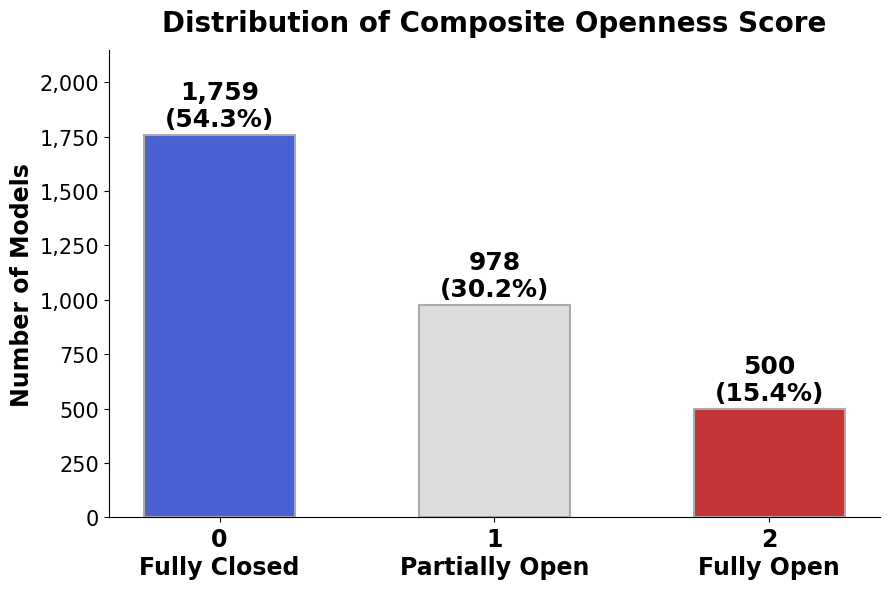

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.cm as cm

df = pd.read_csv("dataset/cleaned_ai_models.csv")

# --- Composite openness score ---
df["open_weights"] = df["Open model weights?"].map({"Yes": 1, "No": 0})
df["open_code"]    = df["Training code accessibility"].str.strip().str.startswith("Open").astype(float)
df["open_code"]    = df["open_code"].where(df["Training code accessibility"].str.strip() != "", np.nan)

df["openness_score"] = df[["open_weights", "open_code"]].sum(axis=1, min_count=1)
scored = df.dropna(subset=["openness_score"])
scored["openness_score"] = scored["openness_score"].astype(int)

counts = scored["openness_score"].value_counts().sort_index()
pct    = (counts / counts.sum() * 100).round(1)

print("=== Composite Openness Score Distribution ===")
summary = pd.DataFrame({"Count": counts, "Percent (%)": pct})
summary.index.name = "Score"
print(summary)
print(f"\nTotal scored models: {len(scored)}")
print(f"  Score 0 (fully closed):   {counts.get(0, 0)} ({pct.get(0, 0)}%)")
print(f"  Score 1 (partially open): {counts.get(1, 0)} ({pct.get(1, 0)}%)")
print(f"  Score 2 (fully open):     {counts.get(2, 0)} ({pct.get(2, 0)}%)")

# --- Histogram ---
plt.rcParams["font.family"] = "DejaVu Sans"

# Pull colors directly from coolwarm at 0, 0.5, 1
coolwarm = cm.get_cmap("coolwarm")
colors = [coolwarm(0.05), coolwarm(0.5), coolwarm(0.95)]

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    counts.index, counts.values,
    color=colors, edgecolor="#aaaaaa", linewidth=1.5, width=0.55
)

for bar, count, p in zip(bars, counts.values, pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        f"{count:,}\n({p}%)",
        ha="center", va="bottom",
        fontsize=18, fontweight="bold"
    )

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(
    ["0\nFully Closed", "1\nPartially Open", "2\nFully Open"],
    fontsize=17, fontweight="bold"
)
ax.set_ylabel("Number of Models", fontsize=17, fontweight="bold")
ax.set_title("Distribution of Composite Openness Score", fontsize=20, fontweight="bold", pad=14)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(axis="y", labelsize=15)
ax.set_ylim(0, counts.max() * 1.22)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## Chi-Square Test #1: Openness by Organization Type

**H₀:** Openness is independent of organization type (Industry vs. Academia)  
**H₁:** Industry and Academic organizations differ in their rate of open model releases  

Since `Organization categorization` can contain multiple orgs (e.g. `"Industry,Academia"`), a row is flagged as Industry if "Industry" appears anywhere in the string.

In [61]:
import pandas as pd
import numpy as np
from scipy import stats

df = pd.read_csv("dataset/cleaned_ai_models.csv")
df["open"] = df["Open model weights?"].map({"Yes": 1, "No": 0})
df["is_industry"] = df["Organization categorization"].str.contains("Industry", na=False).astype(int)

ct = df.dropna(subset=["open"])
ct = ct[ct["Organization categorization"].notna() & (ct["Organization categorization"].str.strip() != "")]

contingency = pd.crosstab(
    ct["is_industry"].map({1: "Industry", 0: "Academia / Other"}),
    ct["open"].map({1: "Open", 0: "Closed"}),
    margins=True
)
print("=== Contingency Table ===")
print(contingency)

# Row percentages
pct = pd.crosstab(
    ct["is_industry"].map({1: "Industry", 0: "Academia / Other"}),
    ct["open"].map({1: "Open", 0: "Closed"}),
    normalize="index"
).mul(100).round(1)
print("\n=== Row Percentages (%) ===")
print(pct)

chi2, p, dof, expected = stats.chi2_contingency(
    pd.crosstab(ct["is_industry"], ct["open"])
)
n = contingency.loc["All", "All"]
cramers_v = np.sqrt(chi2 / (n * (min(2, 2) - 1)))

print(f"\n=== Chi-Square Results ===")
print(f"  χ²({dof})  = {chi2:.4f}")
print(f"  p-value   = {p:.4e}")
print(f"  N         = {n}")
print(f"  Cramér's V = {cramers_v:.4f}  (effect size: small<0.1, medium<0.3, large≥0.3)")
print(f"\n  {'REJECT' if p < 0.05 else 'FAIL TO REJECT'} H₀ at α=0.05")

=== Contingency Table ===
open              Closed  Open   All
is_industry                         
Academia / Other     229   278   507
Industry             992   961  1953
All                 1221  1239  2460

=== Row Percentages (%) ===
open              Closed  Open
is_industry                   
Academia / Other    45.2  54.8
Industry            50.8  49.2

=== Chi-Square Results ===
  χ²(1)  = 4.8738
  p-value   = 2.7268e-02
  N         = 2460
  Cramér's V = 0.0445  (effect size: small<0.1, medium<0.3, large≥0.3)

  REJECT H₀ at α=0.05


## Chi-Square Test #2: Openness by Domain

**H₀:** Openness is independent of the model's domain  
**H₁:** Openness rates differ across domains  

Domain can be multi-valued (e.g. `"Language,Vision"`). The **primary domain** is taken as the first entry. Domains with fewer than 20 labeled models are grouped into `"Other"` to keep expected cell counts valid.

In [62]:
import pandas as pd
import numpy as np
from scipy import stats

df = pd.read_csv("dataset/cleaned_ai_models.csv")
df["open"] = df["Open model weights?"].map({"Yes": 1, "No": 0})
df["primary_domain"] = df["Domain"].str.split(",").str[0].str.strip()

dm = df.dropna(subset=["open"])
dm = dm[dm["primary_domain"].notna() & (dm["primary_domain"] != "")]

# Group rare domains into "Other"
domain_counts = dm["primary_domain"].value_counts()
rare = domain_counts[domain_counts < 20].index
dm["domain_grouped"] = dm["primary_domain"].where(~dm["primary_domain"].isin(rare), "Other")

contingency = pd.crosstab(dm["domain_grouped"], dm["open"].map({1: "Open", 0: "Closed"}), margins=True)
print("=== Contingency Table ===")
print(contingency)

pct = pd.crosstab(dm["domain_grouped"], dm["open"].map({1: "Open", 0: "Closed"}), normalize="index").mul(100).round(1)
print("\n=== Row Percentages (%) ===")
print(pct)

chi2, p, dof, expected = stats.chi2_contingency(
    pd.crosstab(dm["domain_grouped"], dm["open"])
)
n = contingency.loc["All", "All"]
k = dm["domain_grouped"].nunique()
cramers_v = np.sqrt(chi2 / (n * (min(k, 2) - 1)))

print(f"\n=== Chi-Square Results ===")
print(f"  χ²({dof})  = {chi2:.4f}")
print(f"  p-value   = {p:.4e}")
print(f"  N         = {n}")
print(f"  Cramér's V = {cramers_v:.4f}  (effect size: small<0.1, medium<0.3, large≥0.3)")
print(f"\n  {'REJECT' if p < 0.05 else 'FAIL TO REJECT'} H₀ at α=0.05")

=== Contingency Table ===
open              Closed  Open   All
domain_grouped                      
Audio                 14    10    24
Biology               65   138   203
Games                 35     6    41
Image generation      87    75   162
Language             627   730  1357
Multimodal            83    82   165
Other                 49    38    87
Robotics              34    13    47
Speech                71    30   101
Video                 69    33   102
Vision                89   105   194
All                 1223  1260  2483

=== Row Percentages (%) ===
open              Closed  Open
domain_grouped                
Audio               58.3  41.7
Biology             32.0  68.0
Games               85.4  14.6
Image generation    53.7  46.3
Language            46.2  53.8
Multimodal          50.3  49.7
Other               56.3  43.7
Robotics            72.3  27.7
Speech              70.3  29.7
Video               67.6  32.4
Vision              45.9  54.1

=== Chi-Square Results 

## ANCOVA: Openness ~ log(Compute) + Year

**Question:** Does training compute predict openness *beyond* what year alone explains?

Since the DV is binary, this is implemented as a **logistic regression ANCOVA** using `statsmodels`. Three models are compared:

| Model | Predictors | Purpose |
|---|---|---|
| M1 | Year only | Time trend baseline |
| M2 | log(Compute) only | Raw size effect |
| M3 | log(Compute) + Year | Compute effect controlling for time |

A likelihood-ratio test (M1 vs M3) tells us whether compute adds explanatory power over and above year.

In [63]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("dataset/cleaned_ai_models.csv")
df["open"]        = df["Open model weights?"].map({"Yes": 1, "No": 0})
df["log_compute"] = np.log10(pd.to_numeric(df["Training compute (FLOP)"], errors="coerce"))
df["year"]        = pd.to_datetime(df["Publication date"], errors="coerce").dt.year

anc = df[["open", "log_compute", "year"]].dropna()
print(f"N (complete cases for ANCOVA): {len(anc)}\n")

# --- Fit three models ---
m1 = smf.logit("open ~ year",                  data=anc).fit(disp=0)
m2 = smf.logit("open ~ log_compute",            data=anc).fit(disp=0)
m3 = smf.logit("open ~ log_compute + year",     data=anc).fit(disp=0)

def summary_row(label, model):
    return {
        "Model": label,
        "Log-Likelihood": round(model.llf, 2),
        "AIC": round(model.aic, 2),
        "BIC": round(model.bic, 2),
        "Pseudo-R²": round(model.prsquared, 4),
    }

summary = pd.DataFrame([summary_row("M1: Year only", m1),
                         summary_row("M2: log(Compute) only", m2),
                         summary_row("M3: log(Compute) + Year", m3)])
print("=== Model Comparison ===")
print(summary.to_string(index=False))

# --- Likelihood-ratio test: M1 vs M3 ---
lr_stat = 2 * (m3.llf - m1.llf)
lr_df   = m3.df_model - m1.df_model
lr_p    = stats.chi2.sf(lr_stat, lr_df)

print(f"\n=== Likelihood-Ratio Test (M1 vs M3: does compute add over year?) ===")
print(f"  LR χ²({int(lr_df)}) = {lr_stat:.4f}")
print(f"  p-value           = {lr_p:.4e}")
print(f"  {'Compute adds significant explanatory power beyond year.' if lr_p < 0.05 else 'Compute does NOT add significant power beyond year.'}")

# --- Coefficients for M3 ---
print(f"\n=== M3 Coefficients (log-odds) ===")
coef_df = pd.DataFrame({
    "Coefficient": m3.params.round(4),
    "Std Error":   m3.bse.round(4),
    "z":           m3.tvalues.round(3),
    "p-value":     m3.pvalues.map(lambda x: f"{x:.4e}"),
    "Odds Ratio":  np.exp(m3.params).round(4),
})
print(coef_df)

N (complete cases for ANCOVA): 1163

=== Model Comparison ===
                  Model  Log-Likelihood     AIC     BIC  Pseudo-R²
          M1: Year only         -686.81 1377.63 1387.75     0.1220
  M2: log(Compute) only         -716.85 1437.71 1447.82     0.0836
M3: log(Compute) + Year         -684.36 1374.73 1389.91     0.1251

=== Likelihood-Ratio Test (M1 vs M3: does compute add over year?) ===
  LR χ²(1) = 4.8998
  p-value           = 2.6860e-02
  Compute adds significant explanatory power beyond year.

=== M3 Coefficients (log-odds) ===
             Coefficient  Std Error      z     p-value  Odds Ratio
Intercept      -558.3712    73.2274 -7.625  2.4373e-14      0.0000
log_compute       0.0812     0.0366  2.219  2.6471e-02      1.0846
year              0.2755     0.0365  7.556  4.1551e-14      1.3172


## Table 1: Descriptive Statistics

Summary statistics for all variables entering the analysis, formatted for inclusion in the paper.

In [65]:
import pandas as pd
import numpy as np

df = pd.read_csv("dataset/cleaned_ai_models.csv")

# --- Encode all variables ---
df["open_weights"] = df["Open model weights?"].map({"Yes": 1, "No": 0})
df["open_code"]    = df["Training code accessibility"].str.strip().str.startswith("Open").astype(float)
df["open_code"]    = df["open_code"].where(df["Training code accessibility"].str.strip() != "", np.nan)
df["openness_score"] = df[["open_weights", "open_code"]].sum(axis=1, min_count=1)

df["log_compute"]  = np.log10(pd.to_numeric(df["Training compute (FLOP)"], errors="coerce"))
df["log_params"]   = np.log10(pd.to_numeric(df["Parameters"], errors="coerce"))
df["year"]         = pd.to_datetime(df["Publication date"], errors="coerce").dt.year
df["is_industry"]  = df["Organization categorization"].str.contains("Industry", na=False).astype(float)
df["is_frontier"]  = df["Frontier model"].astype(float)
df["primary_domain"] = df["Domain"].str.split(",").str[0].str.strip()

N_total = len(df)

rows = []

def cont_row(label, series, note=""):
    s = series.dropna()
    return {"Variable": label, "N": len(s), "Missing (%)": f"{100*(N_total-len(s))/N_total:.1f}%",
            "Mean": f"{s.mean():.2f}", "SD": f"{s.std():.2f}", "Median": f"{s.median():.2f}",
            "Min": f"{s.min():.2f}", "Max": f"{s.max():.2f}", "Note": note}

def binary_row(label, series, note=""):
    s = series.dropna()
    pct = 100 * s.mean()
    return {"Variable": label, "N": len(s), "Missing (%)": f"{100*(N_total-len(s))/N_total:.1f}%",
            "Mean": f"{pct:.1f}% = 1", "SD": f"{s.std():.2f}", "Median": f"{int(s.median())}",
            "Min": "0", "Max": "1", "Note": note}

def ordinal_row(label, series, note=""):
    s = series.dropna()
    vc = s.value_counts().sort_index()
    dist = ", ".join([f"{int(k)}={v} ({100*v/len(s):.0f}%)" for k,v in vc.items()])
    return {"Variable": label, "N": len(s), "Missing (%)": f"{100*(N_total-len(s))/N_total:.1f}%",
            "Mean": f"{s.mean():.2f}", "SD": f"{s.std():.2f}", "Median": f"{s.median():.1f}",
            "Min": f"{s.min():.0f}", "Max": f"{s.max():.0f}", "Note": dist}

def header(label):
    return {"Variable": label, "N":"","Missing (%)":"","Mean":"","SD":"","Median":"","Min":"","Max":"","Note":""}

# --- Total N row ---
rows.append({"Variable": "Total Models in Dataset", "N": N_total, "Missing (%)": "—",
             "Mean": "—", "SD": "—", "Median": "—", "Min": "—", "Max": "—", "Note": "Epoch AI database (all_ai_models.csv)"})

rows.append(header("— DEPENDENT VARIABLE —"))
rows.append(ordinal_row("Openness Score (0–2)",  df["openness_score"], "0=closed, 1=partial, 2=fully open"))
rows.append(binary_row( "Open Weights (binary)", df["open_weights"],   "1=Yes, 0=No"))
rows.append(binary_row( "Open Code (binary)",    df["open_code"],      "1=any open license, 0=unreleased"))

rows.append(header("— KEY PREDICTORS —"))
rows.append(cont_row("log₁₀(Training Compute, FLOP)", df["log_compute"], "log-transformed; raw in FLOP"))
rows.append(cont_row("log₁₀(Parameters)",             df["log_params"],  "log-transformed; raw count"))

rows.append(header("— TIME CONTROL —"))
rows.append(cont_row("Publication Year", df["year"], "extracted from publication date"))

rows.append(header("— CONTROL VARIABLES —"))
rows.append(binary_row("Industry Org",   df["is_industry"], "1=Industry present, 0=Academia/other"))
rows.append(binary_row("Frontier Model", df["is_frontier"], "1=Frontier, 0=not; top-10 compute at release"))

dm = df["primary_domain"].dropna()
dm = dm[dm != ""]
domain_counts = dm.value_counts()
top_domains = domain_counts[domain_counts >= 20]
domain_str = " | ".join([f"{k}: {v} ({100*v/len(dm):.0f}%)" for k,v in top_domains.items()])
rows.append({"Variable": "Primary Domain (categorical)", "N": len(dm),
             "Missing (%)": f"{100*(N_total-len(dm))/N_total:.1f}%",
             "Mean": "—", "SD": "—", "Median": "—", "Min": "—", "Max": "—", "Note": domain_str})

table = pd.DataFrame(rows).set_index("Variable")

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 200)
print("=" * 120)
print("TABLE 1. Descriptive Statistics")
print("=" * 120)
print(table.to_string())
print("=" * 120)

TABLE 1. Descriptive Statistics
                                  N Missing (%)       Mean    SD   Median      Min      Max                                                                                                                                                                                                                                                                            Note
Variable                                                                                                                                                                                                                                                                                                                                                                   
Total Models in Dataset        3237           —          —     —        —        —        —                                                                                                                                                     